# **COMP 2211 Introduction to Artificial Intelligence** #
## Lab 4 - K-Means Clustering ##

![spotify_logo.jpg](https://github.com/najirh/najirh-Spotify-Data-Analysis-using-SQL/blob/main/spotify_logo.jpg?raw=true)

Greetings, fellow AI enthusiasts! 🎶 Welcome to this exciting (or so I think) lab I've prepared for you. Picture this: You're chilling in your HKUST dorm listening to Spotifywhile you work on this lab... wouldn't it be cool if AI could sort them into groups based on different qualities? That's where K-Means Clustering comes into play. In this lab, we'll dive into the most popular tracks in recent years, cluster them by audio features, and create 'playlists' that hit just right for your late-night study sessions or MTR commutes. Without further ado, let's hit the play button!

▶︎ •၊၊||၊|။||||။‌‌‌၊|• 3:25

## **Lab Tasks**

We'll use a dataset of popular tracks from Spotify. The goal is to cluster songs into different groups based on their individual features. **No scikit-learn is allowed**—we're building from scratch with NumPy.

A quick rundown:
1. Upload the dataset to Google Colab and load the dataset.
2. Preprocess: Filter to popular songs, select features.
3. Standardize the data.
4. Implement K-Means from scratch.
5. Find optimal K with the elbow method.
6. Cluster and visualize (with PCA for dimensionality reduction) the resulting clusters.

Dataset: From Kaggle - Spotify Music Analytics Dataset (2015–2025). Download the CSV file and upload to your Colab. The dataset has ~85,000 tracks in total, but we'll filter to songs with a popularity of >=80 only.

Features we'll use:
- danceability: Measure of how suitable a track is for dancing (0–1)
- energy: Measure of intensity and activity (0–1)
- tempo: Track tempo in beats per minute (BPM)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Task 1: Load & Filter
Spotify assigns every track a **popularity score** (0–100) based on streams, saves, likes, and recent activity. Songs with popularity ≥ 80 are the real chart-toppers we'll work with.
<br>

**Your job:**
1. Load the CSV file
2. Filter rows where `popularity >= 80`
3. Select the 3 audio features above
4. Remove rows with missing values
5. Check how many tracks there are in total

In [4]:
def load_n_filter(file_name, features):
    # TODO: Load your downloaded CSV
    df=pd.read_csv(file_name)

    # TODO: Keep only songs with popularity >= 80
    df_filtered=df[df['popularity']>=80]

    # TODO: Select the 3 audio features for clustering and drop any rows with missing values
    df_filtered=df_filtered[features]
    df_filtered=df_filtered.dropna()

    return df_filtered

if __name__ == "__main__":
    features = ['danceability', 'energy', 'tempo']
    df_popular = load_n_filter('spotify_2015_2025_85k.csv', features)
    # Convert to NumPy array
    X = df_popular.to_numpy()

    print(f"Number of popular songs (popularity ≥ 80): {X.shape[0]}")
    print(f"Clustering on {X.shape[1]} audio features")
    # print(X)
    # print(df_popular.info())

Number of popular songs (popularity ≥ 80): 2971
Clustering on 3 audio features


**Expected output:**
<br>

Number of popular songs (popularity ≥ 80): 2971
<br>
Clustering on 3 audio features

### Task 2: Standardize the Features
**Why standardize?**
<br>

Different features have wildly different scales, e.g.:
- danceability and energy are 0–1
- tempo is ~60–200 BPM
<br>

If we don't standardize, features with larger numbers (like tempo) will dominate the distance calculation — very unfair!
<br>

**Your job:** Use z-score standardization (mean=0, std=1 for every feature) - this makes every feature equally important. (Note: use the **default** ddof=1)

In [5]:
# Note the following code is forbidden.
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_norm = scaler.fit_transform(X)
# print("No points for you!")

def standardize(X):
    # TODO: Standardize the features
    mean = X.mean(axis=0)
    # Calculate standard deviation 
    std = X.std(axis=0)
    
    X_norm=(X-mean)/std

    return X_norm

if __name__ == "__main__":
    X_norm = standardize(X)
    print(X_norm[:5])

[[ 1.20737139 -1.09716711 -0.56916586]
 [ 1.57182892  1.0684957  -0.16371839]
 [-0.25045875  0.85192942  0.58026044]
 [ 0.04110728  1.46553389  1.70845136]
 [ 0.04110728 -0.66403454  0.60050812]]


**Expected output:**
<br>

In [6]:
# np.array([[ 1.20737139, -1.09716711, -0.56916586],
#        [ 1.57182892,  1.0684957 , -0.16371839],
#        [-0.25045875,  0.85192942,  0.58026044],
#        [ 0.04110728,  1.46553389,  1.70845136],
#        [ 0.04110728, -0.66403454,  0.60050812]])

### Task 3: Implement K-Means from Scratch (NumPy Only)
**Background reminder (from lecture):**
K-Means is an iterative algorithm that:
1. Picks K random centroids
2. Assigns each point to the nearest centroid
3. Moves each centroid to the mean of its assigned points
4. Repeats until centroids barely move
<br>

**Your job:** Implement the four key functions above.

In [7]:
def initialize_centroids(X, k):
    """
    Randomly pick k points as initial centroids
    return a 2D numpy array of the centroids
    """
    # TODO 1
    # hint: use np.random.choice()
    n_samples = X.shape[0]

    # Randomly select k unique indices from 0 to n_samples-1
    random_indices = np.random.choice(n_samples, size=k, replace=False)
    # Use indices 
    centroids = X[random_indices]
    return centroids

def assign_labels(X, centroids):
    """
    Assign each point to the nearest centroid (using Euclidean distance)
    return a 1D numpy array of labels (which cluster) assigned to each point
    """
    # TODO 2
    #shape:(1d numofsamples)

    n_samples = X.shape[0]
    k = centroids.shape[0]
    labels = np.zeros(n_samples, dtype=int)  # Initialize labels array
    
    for i in range(n_samples):
        # np.linalg.norm(a - b) = sqrt(sum((a-b)^2)) (Euclidean distance)
        distances = np.linalg.norm(X[i] - centroids, axis=1)

        # Assign label = index of the closest centroid (smallest distance)
        labels[i] = np.argmin(distances)
         
    return labels
    # hint: use np.linalg.norm() to make your life easier


def update_centroids(X, labels, k):
    """
    Update the position of each centroid by computing the mean of points in each cluster
    return a 2D numpy array of the updated centroids
    """
    # TODO 3
    """
    Returns:
        np.ndarray: Updated centroids (shape: [k, n_features])
    """
    n_features = X.shape[1]
    new_centroids = np.zeros((k, n_features))  # Initialize new centroids
    
    for cluster in range(k):
        # Get all points assigned to this cluster
        cluster_points = X[labels == cluster]
        # If cluster has no points, keep old centroid (or random point to avoid empty cluster)
        if len(cluster_points) == 0:
            # Re-initialize 
            new_centroids[cluster] = X[np.random.choice(X.shape[0])]
        else:
            # Update centroid 
            new_centroids[cluster] = np.mean(cluster_points, axis=0)
    
    return new_centroids

def kmeans(X, k, max_iter=75):
    """
    Main K-Means loop
    return both the final centroids and labels
    """
    # TODO 4
    # ...
    centroids = initialize_centroids(X, k)

    for i in range(max_iter):
        # ...
        labels = assign_labels(X, centroids)
        new_centroids = update_centroids(X, labels, k)
        differences = np.linalg.norm(new_centroids - centroids, axis=1)
        

        if np.all(differences < 1e-2):
            print(f"K-Means converged after {i+1} iterations!")
            break
        centroids=new_centroids
        # if i==max_iter-1:
        #      print('end')
        # ...

    return centroids, labels


In [12]:
if __name__ == "__main__":
    np.random.seed(42)

    test_X = np.array([[1, 2, 3, 4], [2, 4, 6, 8], [4, 8, 10, 12]])
    test_k = 2

    print("centroids:\n", centroids := initialize_centroids(test_X, test_k))
    print("labels:\n", labels := assign_labels(test_X, centroids))
    print("updated centroids:\n", centroids := update_centroids(test_X, labels, test_k))

    centroids, labels = kmeans(X_norm, 4)
    print("final centroids:", centroids)
    print("final labels:", labels)

centroids:
 [[1 2 3 4]
 [2 4 6 8]]
labels:
 [0 1 1]
updated centroids:
 [[ 1.  2.  3.  4.]
 [ 3.  6.  8. 10.]]
K-Means converged after 9 iterations!
final centroids: [[ 0.84236467 -0.32034682  0.88447796]
 [ 0.69535411  0.36907685 -0.9525591 ]
 [-0.77847892 -0.9111835  -0.31410948]
 [-0.84898017  0.87427601  0.49760254]]
final labels: [1 1 3 ... 2 3 2]


**Expected output:**
<br>

In [9]:
# centroids:
#  [[1 2 3 4]
#  [2 4 6 8]]
# labels:
#  [0 1 1]
# updated centroids:
#  [[ 1.  2.  3.  4.]
#  [ 3.  6.  8. 10.]]
# K-Means converged after 9 iterations!
# final centroids: [[ 0.84236467 -0.32034682  0.88447796]
#  [ 0.69535411  0.36907685 -0.9525591 ]
#  [-0.77847892 -0.9111835  -0.31410948]
#  [-0.84898017  0.87427601  0.49760254]]
# final labels: [1 1 3 ... 2 3 2]

### Task 4: The Elbow Method
**What is the Elbow Method?**
<br>

K-Means needs you to pick K (number of clusters) before running.
But how do you choose the best K?
The **Elbow Method** is the classic, intuitive answer.
<br>

**Core idea:**
As you increase K, points get closer to their cluster centers → total error (inertia) keeps dropping.
But after a certain K, adding more clusters helps almost nothing — the curve flattens like an **elbow**.
<br>

**How to calculate Inertia (Within-Cluster Sum of Squares):**
<br>
Inertia = Σ (distance from each point to its closest centroid)²
<br>

**Your job:**
1. Run K-Means for K=2 to 18
2. Calculate the inertia for each run **(without using any form of loops)**
3. Plot K vs inertia
4. Choose your `optimal_K` where the curve starts flattening (since this is largely intuition-based, the optimal K will not be graded)

Running K-Means for K=2...
K-Means converged after 9 iterations!
Running K-Means for K=3...
K-Means converged after 10 iterations!
Running K-Means for K=4...
K-Means converged after 42 iterations!
Running K-Means for K=5...
K-Means converged after 23 iterations!
Running K-Means for K=6...
K-Means converged after 16 iterations!
Running K-Means for K=7...
K-Means converged after 12 iterations!
Running K-Means for K=8...
K-Means converged after 28 iterations!
Running K-Means for K=9...
K-Means converged after 43 iterations!
Running K-Means for K=10...
K-Means converged after 15 iterations!
Running K-Means for K=11...
K-Means converged after 17 iterations!
Running K-Means for K=12...
K-Means converged after 43 iterations!
Running K-Means for K=13...
K-Means converged after 36 iterations!
Running K-Means for K=14...
K-Means converged after 43 iterations!
Running K-Means for K=15...
K-Means converged after 22 iterations!
Running K-Means for K=16...
K-Means converged after 23 iterations!
Runn

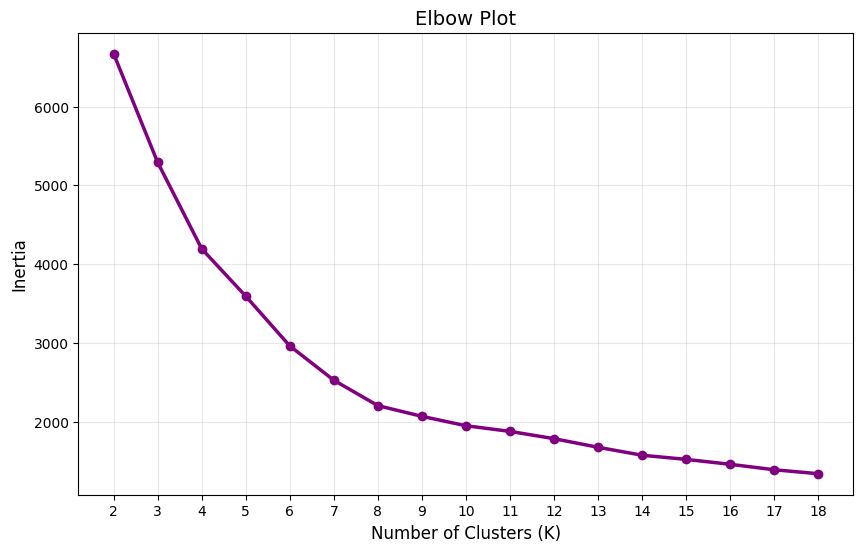

In [10]:
def compute_inertia(X, centroids, labels):
    """
    Calculate inertia with ONLY numpy operations and broadcasting
    return the inertia as a scalar value
    """
    # TODO
    # hint 1: use np.expand_dims() to help you get the right shape (3D) for broadcasting (very difficult I agree)
    # hint 2: use np.arange() and labels array to help you get the mask array (also difficult)
    # hint 3: multiply the 3D inertias array ((n_samples, k, n_features) or (n_samples, k) depending on whether you used np.sum() during broadcasting) with the mask array to help you compute the final sum
    # The Ultimate Hint: print the shapes of the numpy arrays as you code
    n_samples = X.shape[0]
    k = centroids.shape[0]
    n_features = X.shape[1]
    
    # centroids[labels] : (n_samples, n_features)，
    sample_centers = centroids[labels]
    
    # 计算每个样本到自己中心的距离平方 then sum them
    squared_dist = np.sum((X - sample_centers) ** 2, axis=1)
    
    
    inertia = np.sum(squared_dist)
    
    return inertia

#     #2. Reshape arrays for 3D broadcasting 

#     # X: turn into (n_samples, 1, n_features)
#     X_3d = np.expand_dims(X, axis=1)  # Same as X[:, None, :]
    
#     # centroids: (k, n_features) → (1, k, n_features)
#     centroids_3d = np.expand_dims(centroids, axis=0) 

# # 3: Compute squared distance for ALL (sample, centroid) pairs (3D array)
#     # Shape: (n_samples, k, n_features) → squared diff per feature
#     squared_diff_3d = (X_3d - centroids_3d) **2

#     # Sum over features to get squared distance (shape: (n_samples, k))
#     squared_dist_2d = np.sum(squared_diff_3d, axis=2)

def compute_all_inertias(X):
    inertias = []
    for k in range(2, 19):
        print(f"Running K-Means for K={k}...")
        # TODO: Run the elbow method on different k values
        centroids, labels = kmeans(X, k)
        inertia = compute_inertia(X, centroids, labels)
        inertias.append(inertia)

    return inertias

# Plot the elbow!
if __name__ == "__main__":
    np.random.seed(42)
    plt.figure(figsize=(10, 6))
    plt.plot(range(2, 19), compute_all_inertias(X_norm), marker='o', color='purple', linewidth=2.5)
    plt.xlabel('Number of Clusters (K)', fontsize=12)
    plt.ylabel('Inertia', fontsize=12)
    plt.title('Elbow Plot', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.xticks(range(2, 19))
    plt.show()

### Task 5: Run Final Clustering & Visualize the Clusters (Ungraded)

K-Means converged after 11 iterations!


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


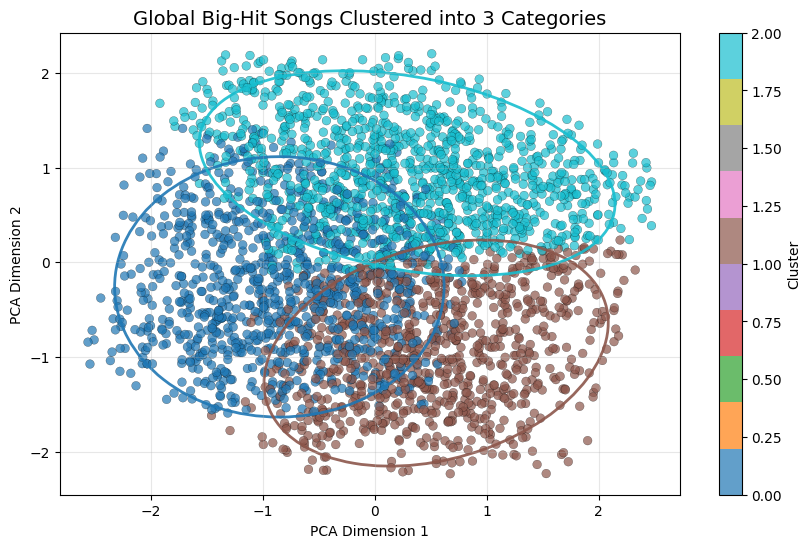

Cluster characteristics (average feature values):
         danceability  energy    tempo
cluster                               
0               0.771   0.321  125.161
1               0.261   0.331  135.658
2               0.530   0.787  130.507


In [11]:
if __name__ == "__main__":
    # After looking at the plot above, decide the optimal k
    optimal_K = 3
    centroids, labels = kmeans(X_norm, optimal_K)

    # Reduce to 2D for better visualization using PCA (the principle behind PCA is beyond the scope of this lab)
    from sklearn.decomposition import PCA # only for visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_norm)

    plt.figure(figsize=(10, 6))
    # Scatter of actual songs
    scatter = plt.scatter(
        X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10',
        alpha=0.7, s=40, edgecolor='k', linewidth=0.2
    )

    # Draw an ellipse for each cluster in PCA space
    from matplotlib.patches import Ellipse
    import matplotlib as mpl

    colors = mpl.cm.tab10(np.linspace(0, 1, optimal_K))

    for k in range(optimal_K):
        cluster_points = X_pca[labels == k]
        if cluster_points.shape[0] < 2:
            continue  # need at least 2 points for covariance

        # Mean and covariance in PCA space
        mean = cluster_points.mean(axis=0)
        cov = np.cov(cluster_points, rowvar=False)

        # Eigen-decomposition to get principal axes
        vals, vecs = np.linalg.eigh(cov)
        # Sort eigenvalues and eigenvectors
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]

        # Width and height of ellipse: ~95% coverage (2 std devs along each principal axis)
        width, height = 2 * 2 * np.sqrt(vals)

        # Angle of the ellipse (in degrees)
        angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

        ell = Ellipse(
            xy=mean,
            width=width,
            height=height,
            angle=angle,
            facecolor='none',
            edgecolor=colors[k],
            linewidth=2,
            alpha=0.9,
        )
        plt.gca().add_patch(ell)

    plt.colorbar(scatter, label='Cluster')
    plt.title(f'Global Big-Hit Songs Clustered into {optimal_K} Categories', fontsize=14)
    plt.xlabel('PCA Dimension 1')
    plt.ylabel('PCA Dimension 2')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Show what each cluster "sounds" like on average
    df_hits = df_popular.copy()
    df_hits['cluster'] = labels
    print("Cluster characteristics (average feature values):")
    print(df_hits.groupby('cluster')[features].mean().round(3))

## Grading Scheme (10 points total)
Hidden testcases will check K-Means correctness on a hidden dataset. (Don't worry about this one; as long as you didn't hard-code anything in your code you'll 100% pass them)
- 2 pts — Filtering (popularity ≥ 80) + feature selection
- 1 pts — Standardization (without scikit-learn)
- 4 pts — Clean from-scratch K-Means implementation
- 3 pts — Calculation of inertia (no loops) + Elbow plot

**Submission:**
Download the notebook as python (.py) script and zip it and submit it on Zinc
<br>

Hope you had fun fellow music lovers! 🎤✨